In [157]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scipy.cluster.hierarchy import dendrogram, linkage



In [34]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

In [35]:
df.dropna(inplace = True)

In [36]:
df = pd.get_dummies(df)

In [37]:
df. describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [39]:
df.head(10)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
5,1,1,0,0,1,1,1,34,450.743960,1.0,3,2.623477,2.637007,0
6,1,1,1,1,0,6,1,32,94.266389,6.0,2,1.138941,1.277242,0
7,0,1,0,0,1,1,0,30,217.786641,1.0,0,1.213502,1.049387,1
8,1,1,1,1,1,1,1,23,45.409909,1.0,1,1.106239,1.059333,0
9,0,1,0,0,1,1,0,31,65.310836,1.0,11,1.810852,1.951368,0


In [69]:
# Agrupar por la columna 'Churn' y calcular la media
churn_means = df.groupby('Churn').mean().T
print(churn_means)

Churn                                       0           1
gender                               0.516149    0.506147
Near_Location                        0.929311    0.786774
Partner                              0.716027    0.327257
Promo_friends                        0.511883    0.167020
Phone                                0.895795    0.908860
Contract_period                      9.108470    1.601526
Group_visits                         0.543571    0.320899
Age                                 30.043266   28.586689
Avg_additional_charges_total       162.812449  135.904910
Month_to_end_contract                8.316271    1.544722
Lifetime                             4.889092    2.914794
Avg_class_frequency_total            2.185609    1.665746
Avg_class_frequency_current_month    2.183361    1.477453


In [64]:
# Separar variables para una mejor visualización
# Variables binarias/categóricas
categorical_cols = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits']
# Variables numéricas continuas
numerical_cols = ['Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

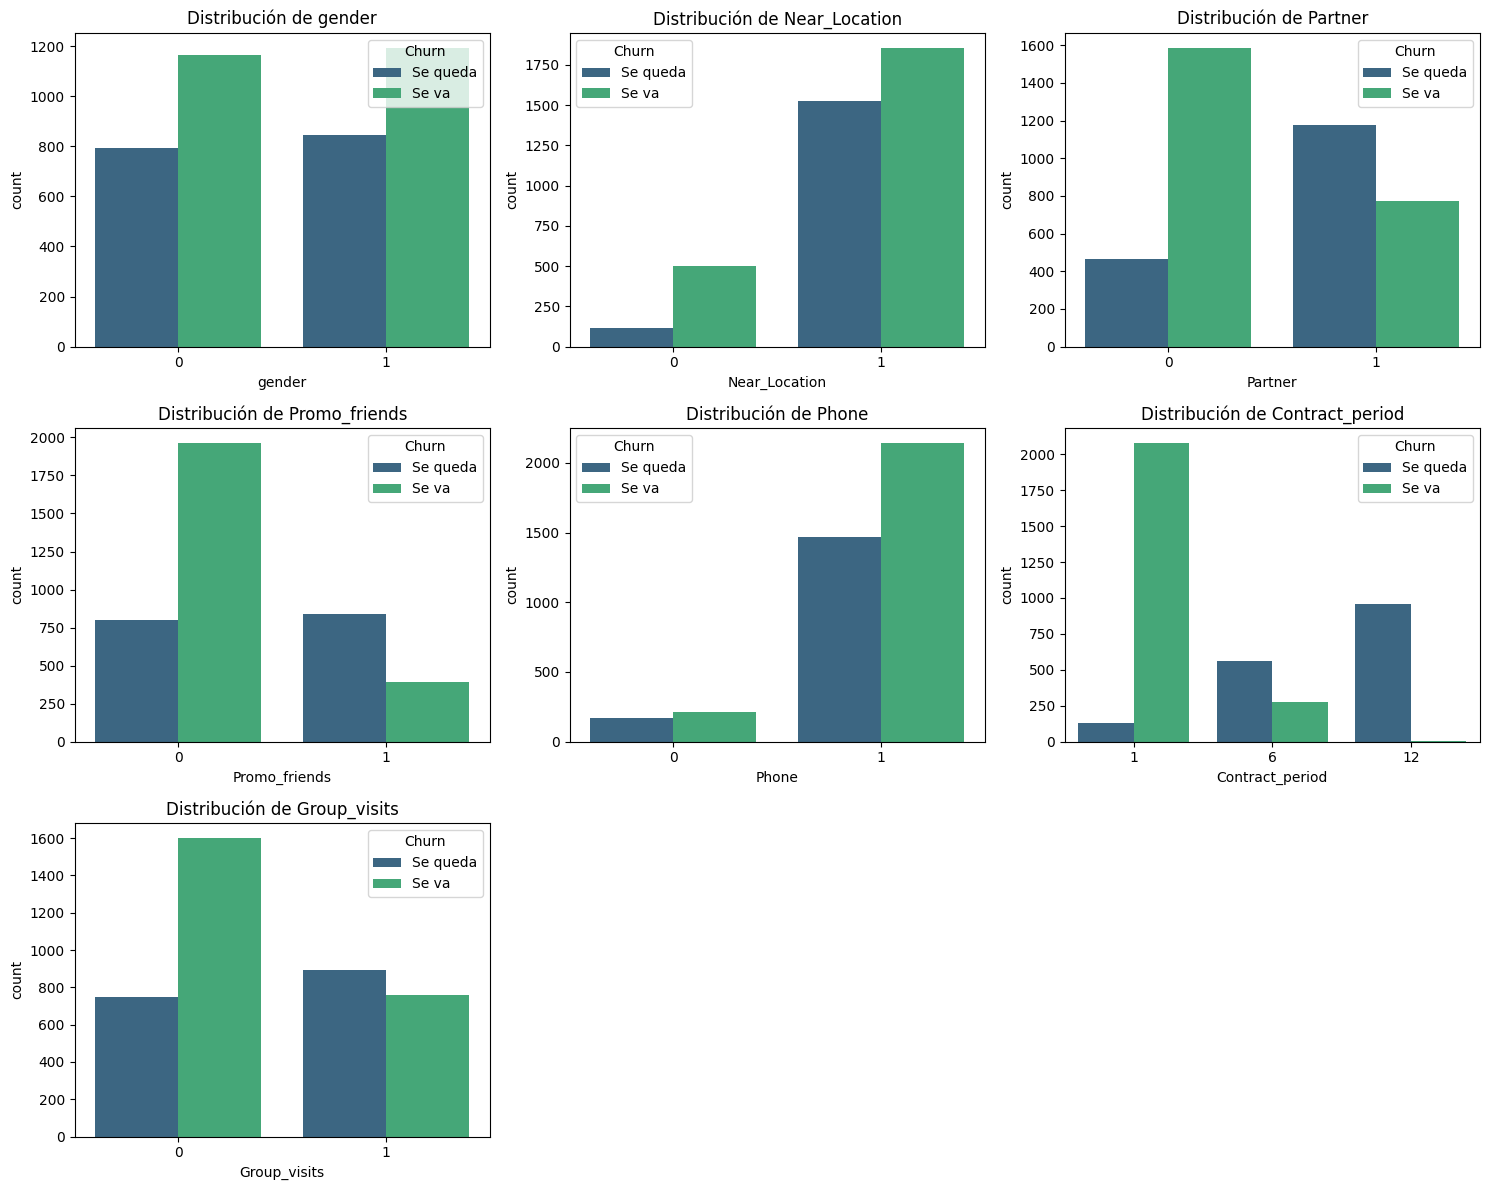

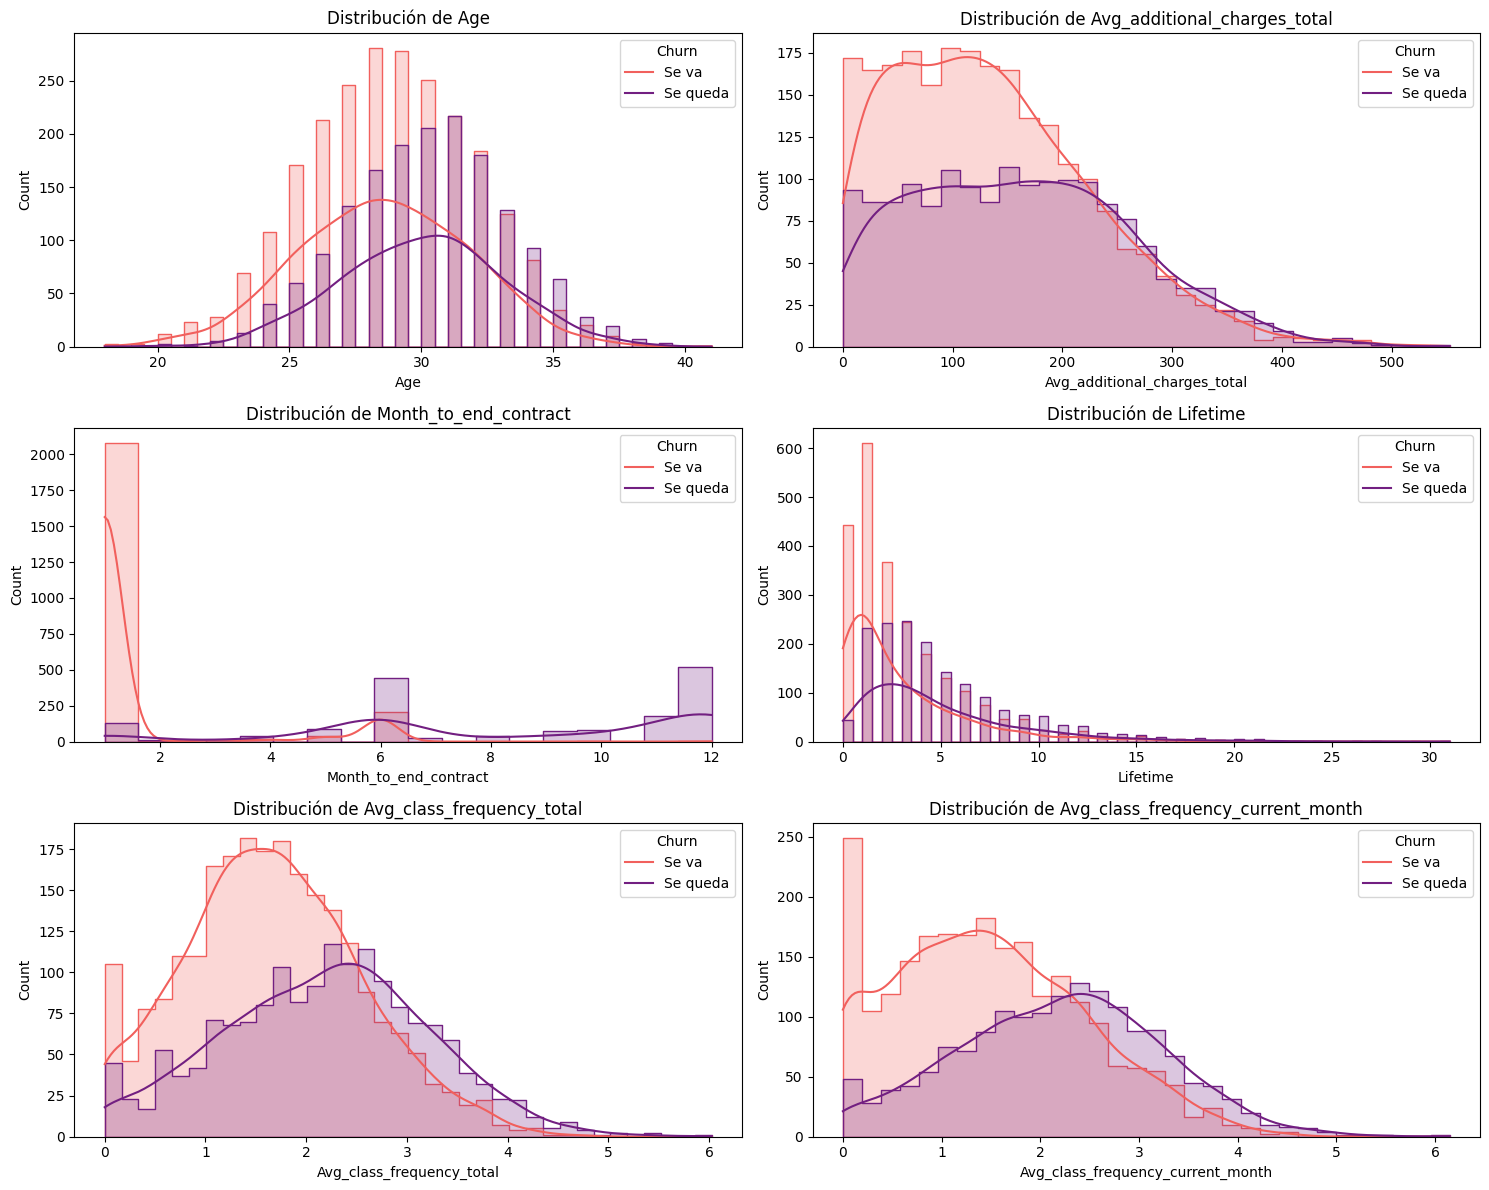

In [65]:
# 1. Histogramas para variables categóricas (Gráficos de barras de conteo)
plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='Churn', data=df, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.legend(title='Churn', labels=['Se queda', 'Se va'])

plt.tight_layout()
plt.show()

# 2. Distribuciones para variables numéricas (Histogramas con densidad)
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element="step", palette='magma', common_norm=False)
    plt.title(f'Distribución de {col}')
    plt.legend(title='Churn', labels=['Se va', 'Se queda']) # Invertido por el orden de renderizado de seaborn

plt.tight_layout()
plt.show()

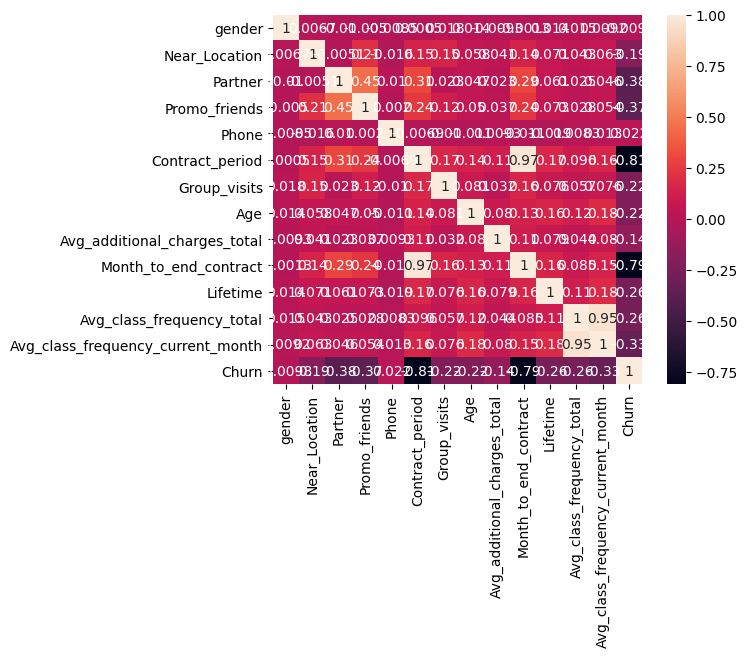

In [104]:
cm = df.corr()   # calcula la matriz de correlación
fig, ax = plt.subplots()
sns.heatmap(cm, annot = True, square=True) # escribe tu código aquí
ax.set_ylim(14, 0) 
plt.show()


In [145]:

X = df.drop('Churn', axis = 1)
y = df['Churn']


# divide los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [146]:

# entrena StandardScaler en el conjunto de entrenamiento
scaler = StandardScaler()
scaler.fit(X_train)

# transforma conjuntos de entrenamiento y de prueba
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

In [147]:
# define la función que podrá generar nuestras métricas
def print_all_metrics(y_true, y_pred, y_proba, title = 'Métricas de clasificación'):
    print(title)
    print('\tAccuracy: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))
    print('\tF1: {:.2f}'.format(f1_score(y_true, y_pred)))
    print('\tROC_AUC: {:.2f}'.format(roc_auc_score(y_true, y_proba)))

In [148]:
# define el algoritmo para el modelo de regresión logística
lr_model = LogisticRegression(random_state=1)
# entrena el modelo 
lr_model.fit(X_train_st, y_train)
# utiliza el modelo entrenado para hacer previsiones
lr_predictions = lr_model.predict(X_test_st)
lr_probabilities = lr_model.predict_proba(X_test_st)[:,1]
# muestra todas las métricas
print_all_metrics(y_test, lr_predictions, lr_probabilities , title='Métricas de regresión logística:')

Métricas de regresión logística:
	Accuracy: 0.98
	Precision: 0.98
	Recall: 0.98
	F1: 0.98
	ROC_AUC: 1.00


In [149]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 1)
# entrena el modelo de random forest
rf_model.fit(X_train_st, y_train)
# utiliza el modelo entrenado para hacer previsiones
rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:,1]
# muestra todas las métricas
print_all_metrics(y_test, rf_predictions, rf_probabilities, title='Métricas de random forest:')

Métricas de random forest:
	Accuracy: 0.98
	Precision: 0.98
	Recall: 0.98
	F1: 0.98
	ROC_AUC: 1.00


In [151]:

# define la función para representar gráficos de características pareadas para los clústeres
def show_clusters_on_plot(df, x_name,y_name, cluster_name):
    plt.figure(figsize = (10,10))
    sns.scatterplot(df[x_name], df[y_name],
          hue = df[cluster_name], palette = 'Paired'
       )
    plt.title('{} vs {}'.format(x_name, y_name))
    plt.show()

In [152]:
sc_2 = StandardScaler()
x_sc_2 = sc_2.fit_transform(df)

In [153]:
# define el modelo k_means con 5 clústeres
km = KMeans(n_clusters=5)

# predice los clústeres para las observaciones (el algoritmo les asigna un número de 0 a 4)
labels = km.fit_predict(x_sc_2)

# almacena etiquetas de clúster en el campo de nuestro conjunto de datos
df['cluster_km'] = labels

In [155]:
# obtiene las estadísticas de los valores medios de las características por clúster
df.groupby(['cluster_km']).mean()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,0.497053,0.000000,0.445972,0.064833,0.915521,1.758350,0.196464,28.483301,133.303824,1.681729,2.669941,1.646983,1.442726,0.976424
1,0.509615,0.930288,0.658654,0.465144,0.919471,7.823317,0.539663,30.274038,163.014585,7.063702,5.145433,2.969845,2.974827,0.000000
2,0.542595,0.992136,0.158585,0.091743,0.903014,1.281782,0.384010,29.644823,152.248143,1.254260,4.065531,2.437533,2.397059,1.000000
3,0.524467,0.942284,0.774153,0.565872,0.869511,10.496863,0.549561,29.801757,162.517502,9.663739,4.637390,1.372220,1.362178,0.000000
4,0.484076,1.000000,0.394904,0.266606,0.910828,1.798908,0.335760,27.916288,126.117695,1.727934,2.239308,1.140452,0.859137,1.000000


In [158]:
linked = linkage(x_sc_2, method = 'ward')


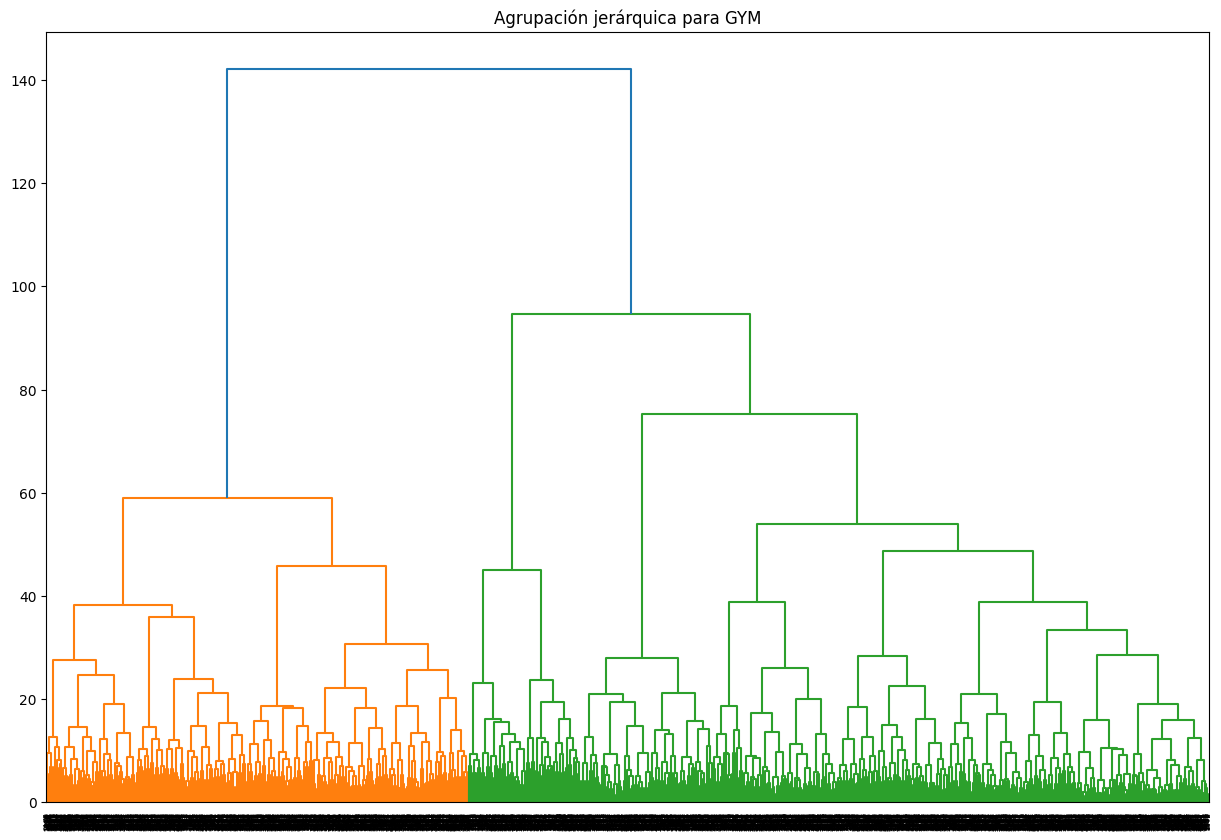

In [159]:
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica para GYM')
plt.show()

In [163]:
# Característica	Grupo de Alto Riesgo (Se va)	 Grupo de Bajo Riesgo (Se queda)
#Edad	Más jóvenes (26-27 años)	                 Adultos más estables (30+ años)
#Vínculo Social	Viene solo (Sin Promo_friends)	     Viene con amigos o por empresa
#Uso de Clases	No participa en Group_visits	     Participa frecuentemente en grupos
#Cercanía	Vive o trabaja lejos del gym	         Vive o trabaja en la zona

